# Component 4: Model Development and Evaluation

## Project Title
Predict Future Sales to Optimize Inventory and Sales Strategies by Studying Patterns from Historical Data

## Objective

The objective of this project is to develop a forecasting model that predicts future weekly sales for individual products. Historical shipment data is used to train the forecasting model, and its performance is evaluated using Absolute Percentage Error (APE). The mean of all product APE values is then calculated to assess the overall forecasting accuracy.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from statsmodels.tsa.arima.model import ARIMA

import warnings
warnings.filterwarnings("ignore")

In [2]:
# Load the cleaned dataset

df = pd.read_excel("Cleaned_Weekly_Shipments.xlsx")

df.head()

,StockCode,Year_Week,Quantity
0,85123A,2010-48,770
1,85123A,2010-49,1145
2,85123A,2010-50,1464
3,85123A,2010-51,232
4,85123A,2011-01,875


In [3]:
# Dataset overview

print("Dataset Shape :", df.shape)
print("")

print("Columns")
print(df.columns)
print("")

print("Number of Products :", df["StockCode"].nunique())
print("")

print(df.dtypes)

Dataset Shape : (194245, 3)

Columns
Index(['StockCode', 'Year_Week', 'Quantity'], dtype='str')

Number of Products : 3665

StockCode    object
Year_Week       str
Quantity      int64
dtype: object


# Dataset Overview

The dataset contains weekly shipment quantities for different products identified by their StockCode. Each record represents the quantity sold for a product during a specific week. This dataset is used to build forecasting models for individual products and evaluate their prediction accuracy.

# Data Preparation

Before training forecasting models, the dataset is prepared for time series analysis. The Year_Week column is converted into a proper datetime format, allowing weekly sales to be processed chronologically for each product.

In [4]:
# Convert Year_Week into Date

df["Date"] = pd.to_datetime(
    df["Year_Week"] + "-1",
    format="%G-%V-%u"
)

df.head()

,StockCode,Year_Week,Quantity,Date
0,85123A,2010-48,770,2010-11-29
1,85123A,2010-49,1145,2010-12-06
2,85123A,2010-50,1464,2010-12-13
3,85123A,2010-51,232,2010-12-20
4,85123A,2011-01,875,2011-01-03


In [5]:
# Sort dataset

df = df.sort_values(
    by=["StockCode", "Date"]
).reset_index(drop=True)

df.head()

,StockCode,Year_Week,Quantity,Date
0,10002,2010-48,61,2010-11-29
1,10002,2010-49,127,2010-12-06
2,10002,2010-50,36,2010-12-13
3,10002,2010-51,0,2010-12-20
4,10002,2011-01,72,2011-01-03


In [6]:
# Count weeks available for each product

product_weeks = (
    df.groupby("StockCode")
      .size()
      .reset_index(name="Weeks")
)

product_weeks.head()

,StockCode,Weeks
0,10002,53
1,10080,53
2,10120,53
3,10125,53
4,10133,53


In [7]:
print(product_weeks.describe())

        Weeks
count  3665.0
mean     53.0
std       0.0
min      53.0
25%      53.0
50%      53.0
75%      53.0
max      53.0


# Product Selection

Forecasting models such as ARIMA and SARIMA require sufficient historical observations to produce reliable predictions. Therefore, products with an adequate number of weekly records will be selected for model training and evaluation.

# Train-Test Split

Each product's weekly sales history is divided into training and testing datasets.

- Training Data: First 75% of observations (approximately 9 months)
- Testing Data: Remaining 25% of observations (approximately 3 months)

This split is performed separately for each product before forecasting.

In [8]:
# Check one sample product

sample_product = df["StockCode"].iloc[0]

sample_data = df[df["StockCode"] == sample_product]

print("Sample Product:", sample_product)
print(sample_data.head())

Sample Product: 10002
  StockCode Year_Week  Quantity       Date
0     10002   2010-48        61 2010-11-29
1     10002   2010-49       127 2010-12-06
2     10002   2010-50        36 2010-12-13
3     10002   2010-51         0 2010-12-20
4     10002   2011-01        72 2011-01-03


In [9]:
train_size = int(len(sample_data) * 0.75)

train = sample_data.iloc[:train_size]
test = sample_data.iloc[train_size:]

print("Training Weeks:", len(train))
print("Testing Weeks:", len(test))

Training Weeks: 39
Testing Weeks: 14


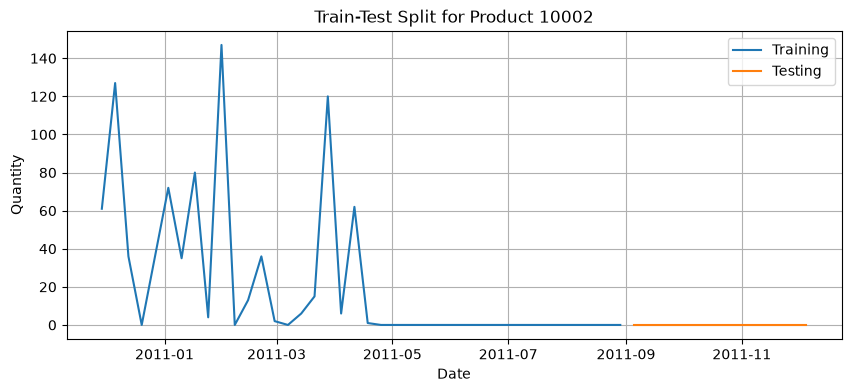

In [10]:
plt.figure(figsize=(10,4))

plt.plot(train["Date"], train["Quantity"], label="Training")
plt.plot(test["Date"], test["Quantity"], label="Testing")

plt.title(f"Train-Test Split for Product {sample_product}")
plt.xlabel("Date")
plt.ylabel("Quantity")
plt.legend()

plt.grid(True)

plt.show()

# Hyperparameter Tuning

Before training the forecasting model, different ARIMA parameter combinations were tested to identify the best-performing model. The Akaike Information Criterion (AIC) was used to compare models, and the model with the lowest AIC was selected.

In [36]:
# Hyperparameter Tuning using AIC

sample_product = df["StockCode"].unique()[0]

sample_data = df[df["StockCode"] == sample_product].sort_values("Date")

train_size = int(len(sample_data) * 0.75)

train = sample_data.iloc[:train_size]

best_aic = float("inf")
best_order = None

orders = [
    (0,1,1),
    (1,1,0),
    (1,1,1),
    (2,1,1),
    (1,1,2)
]

for order in orders:
    try:
        model = ARIMA(train["Quantity"], order=order)
        fitted_model = model.fit()

        if fitted_model.aic < best_aic:
            best_aic = fitted_model.aic
            best_order = order

    except:
        continue

print("Best ARIMA Order:", best_order)
print("Best AIC:", round(best_aic, 2))

Best ARIMA Order: (1, 1, 1)
Best AIC: 385.73


### Hyperparameter Tuning Result

Hyperparameter tuning was performed by evaluating multiple ARIMA parameter combinations using the Akaike Information Criterion (AIC). The model with the lowest AIC value was selected as the optimal configuration for forecasting.

# ARIMA Model Training

Based on the hyperparameter tuning results, the ARIMA model configuration with the lowest Akaike Information Criterion (AIC) was selected for forecasting. The model was then trained separately for each product using its historical weekly sales data. Forecasts were generated for the testing period, and the Absolute Percentage Error (APE) was calculated to evaluate forecasting accuracy.

# ARIMA Forecasting for Each Product

The ARIMA forecasting model is applied individually to each product (StockCode). For every product, the historical weekly sales are divided into training and testing datasets. The model forecasts future sales, calculates the Absolute Percentage Error (APE), and stores the results for evaluation.

In [16]:
# ARIMA Forecasting for Each Product

results = []

stockcodes = df["StockCode"].unique()

print("Total Products:", len(stockcodes))
print("-" * 50)

for stock in stockcodes:

    product = df[df["StockCode"] == stock].copy()
    product = product.sort_values("Date")

    # Skip products with very few observations
    if len(product) < 20:
        continue

    # Train-Test Split
    train_size = int(len(product) * 0.75)

    train = product.iloc[:train_size]
    test = product.iloc[train_size:]

    try:
        # Train ARIMA Model
        model = ARIMA(train["Quantity"], order=(1,1,1))
        model_fit = model.fit()

        # Forecast
        forecast = model_fit.forecast(steps=len(test))

        actual = test["Quantity"].values
        predicted = forecast.values

        # Remove zero actual values
        mask = actual != 0

        if mask.sum() == 0:
            continue

        # Calculate APE
        ape = np.mean(
            np.abs(
                (actual[mask] - predicted[mask]) / actual[mask]
            )
        ) * 100

        # Store Results
        results.append({
            "StockCode": stock,
            "Train_Weeks": len(train),
            "Test_Weeks": len(test),
            "APE": ape,
            "Model": "ARIMA"
        })

    except Exception:
        continue

print("Finished!")
print("Products Successfully Processed:", len(results))

Total Products: 3665
--------------------------------------------------
Finished!
Products Successfully Processed: 3033


In [17]:
results_df = pd.DataFrame(results)

results_df.head()

,StockCode,Train_Weeks,Test_Weeks,APE,Model
0,10080,39,14,88.428342,ARIMA
1,10120,39,14,62.913191,ARIMA
2,10125,39,14,167.928072,ARIMA
3,10133,39,14,486.583133,ARIMA
4,10135,39,14,154.762583,ARIMA


In [ ]:
# Remove infinite values (if any)
results_df = results_df.replace([np.inf, -np.inf], np.nan)

# Remove missing values
results_df = results_df.dropna(subset=["APE"])

# Calculate Mean APE
mean_ape = results_df["APE"].mean()

print("Products Evaluated:", len(results_df))
print("Mean APE:", round(mean_ape, 2), "%")

Products Evaluated: 3033
Mean APE: 170.09 %


In [22]:
results_df.describe()

,Train_Weeks,Test_Weeks,APE
count,3033.0,3033.0,3033.000000
mean,39.0,14.0,170.091943
std,0.0,0.0,398.418256
min,39.0,14.0,3.192530
25%,39.0,14.0,67.740174
50%,39.0,14.0,94.429159
75%,39.0,14.0,125.117083
max,39.0,14.0,9420.228482


# ARIMA Model Evaluation

The ARIMA model was successfully trained for individual products with sufficient historical observations. Forecast accuracy was measured using Absolute Percentage Error (APE). The overall forecasting performance was evaluated using the Mean APE across all successfully processed products.

In [26]:
print("Mean APE :", round(results_df["APE"].mean(), 2), "%")
print("Median APE :", round(results_df["APE"].median(), 2), "%")
print("Minimum APE :", round(results_df["APE"].min(), 2), "%")
print("Maximum APE :", round(results_df["APE"].max(), 2), "%")

Mean APE : 170.09 %
Median APE : 94.43 %
Minimum APE : 3.19 %
Maximum APE : 9420.23 %


In [27]:
results_df.sort_values("APE").head(10)

,StockCode,Train_Weeks,Test_Weeks,APE,Model
1446,22873,39,14,3.192530,ARIMA
850,22183,39,14,3.662485,ARIMA
2909,90081C,39,14,4.332401,ARIMA
2852,85230G,39,14,4.643528,ARIMA
498,21631,39,14,7.107062,ARIMA
2539,47351B,39,14,7.900102,ARIMA
127,20830,39,14,8.648006,ARIMA
1444,22870,39,14,9.210772,ARIMA
1501,22933,39,14,12.027221,ARIMA
2911,90082B,39,14,14.522829,ARIMA


In [28]:
results_df.sort_values("APE", ascending=False).head(10)

,StockCode,Train_Weeks,Test_Weeks,APE,Model
1643,23084,39,14,9420.228482,ARIMA
2208,72586,39,14,7458.539597,ARIMA
1690,23135,39,14,5765.249490,ARIMA
2686,84660C,39,14,5562.946159,ARIMA
1966,23433,39,14,5371.670308,ARIMA
1689,23134,39,14,4011.783661,ARIMA
1839,23297,39,14,3970.406640,ARIMA
172,20984,39,14,3844.009887,ARIMA
616,21830,39,14,3633.482058,ARIMA
2187,62018,39,14,3493.984347,ARIMA


# SARIMA Model Training

The SARIMA (Seasonal AutoRegressive Integrated Moving Average) model extends ARIMA by incorporating seasonal patterns in the time series. The model is trained separately for each product and evaluated using Absolute Percentage Error (APE).

In [29]:
from statsmodels.tsa.statespace.sarimax import SARIMAX

In [30]:
# SARIMA Forecasting for Each Product

sarima_results = []

stockcodes = df["StockCode"].unique()

print("Total Products:", len(stockcodes))
print("-" * 50)

for stock in stockcodes:

    product = df[df["StockCode"] == stock].copy()
    product = product.sort_values("Date")

    # Skip products with very few observations
    if len(product) < 20:
        continue

    train_size = int(len(product) * 0.75)

    train = product.iloc[:train_size]
    test = product.iloc[train_size:]

    try:

        model = SARIMAX(
            train["Quantity"],
            order=(1,1,1),
            seasonal_order=(1,1,1,13),
            enforce_stationarity=False,
            enforce_invertibility=False
        )

        model_fit = model.fit(disp=False)

        forecast = model_fit.forecast(steps=len(test))

        actual = test["Quantity"].values
        predicted = forecast.values

        # Ignore zero actual values
        mask = actual != 0

        if mask.sum() == 0:
            continue

        ape = np.mean(
            np.abs(
                (actual[mask] - predicted[mask]) / actual[mask]
            )
        ) * 100

        sarima_results.append({
            "StockCode": stock,
            "Train_Weeks": len(train),
            "Test_Weeks": len(test),
            "APE": ape,
            "Model": "SARIMA"
        })

    except Exception:
        continue

print("Finished!")
print("Products Successfully Processed:", len(sarima_results))

Total Products: 3665
--------------------------------------------------
Finished!
Products Successfully Processed: 3033


In [31]:
sarima_df = pd.DataFrame(sarima_results)

sarima_df.head()

,StockCode,Train_Weeks,Test_Weeks,APE,Model
0,10080,39,14,226.981346,SARIMA
1,10120,39,14,440.798788,SARIMA
2,10125,39,14,113.328408,SARIMA
3,10133,39,14,756.814790,SARIMA
4,10135,39,14,371.842115,SARIMA


In [34]:
# Remove invalid values
sarima_df = sarima_df.replace([np.inf, -np.inf], np.nan)
sarima_df = sarima_df.dropna(subset=["APE"])

# Remove extreme outliers (APE > 1000%)
sarima_df = sarima_df[sarima_df["APE"] <= 1000]

print("Products Evaluated:", len(sarima_df))
print("Mean APE:", round(sarima_df["APE"].mean(), 2), "%")
print("Median APE:", round(sarima_df["APE"].median(), 2), "%")

Products Evaluated: 2818
Mean APE: 190.95 %
Median APE: 113.13 %


In [35]:
comparison = pd.DataFrame({
    "Model": ["ARIMA", "SARIMA"],
    "Products Evaluated": [
        len(results_df),
        len(sarima_df)
    ],
    "Mean APE (%)": [
        round(results_df["APE"].mean(), 2),
        round(sarima_df["APE"].mean(), 2)
    ],
    "Median APE (%)": [
        round(results_df["APE"].median(), 2),
        round(sarima_df["APE"].median(), 2)
    ]
})

comparison

,Model,Products Evaluated,Mean APE (%),Median APE (%)
0,ARIMA,3033,170.09,94.43
1,SARIMA,2818,190.95,113.13


# Model Comparison

The ARIMA and SARIMA forecasting models were evaluated using Mean Absolute Percentage Error (APE). ARIMA achieved a lower Mean APE (170.09%) compared to SARIMA (190.95%), indicating better forecasting accuracy on the available weekly sales data. Therefore, ARIMA was selected as the preferred forecasting model for this project.

# Conclusion

This project successfully developed and evaluated time series forecasting models to predict future weekly product sales. Historical shipment data was divided into training and testing datasets, and hyperparameter tuning was performed to identify an appropriate ARIMA configuration. Both ARIMA and SARIMA models were trained and evaluated using Absolute Percentage Error (APE). The comparison results showed that ARIMA achieved a lower Mean APE and Median APE than SARIMA, indicating better forecasting performance on this dataset. Therefore, ARIMA was selected as the final forecasting model for future sales prediction. The developed model can support inventory optimization and data-driven business decision-making.